✅ POINT 1

📌 Studi Kasus

Prediksi keterlambatan pengiriman e-commerce

📌 Dataset

* Dataset sekunder dari Kaggle
>https://www.kaggle.com/datasets/prachi13/customer-analytics

* File: Train.csv
>https://drive.google.com/file/d/1Qg7GHPmknWOV7QzsHRAkpxpvnIR_hR-v/view?usp=sharing

* Target: label
>hasil rename dari kolom Reached.on.Time_Y.N

📌 Interpretasi Point 1

>Dataset yang digunakan merupakan dataset sekunder dari Kaggle dengan target variabel label yang merepresentasikan status keterlambatan pengiriman. Variabel target ini diperoleh dari proses penyesuaian nama kolom Reached.on.Time_Y.N untuk memudahkan pemrosesan dan pemodelan menggunakan Apache Spark MLlib..

✅ POINT 2

File System (HDFS / File System Lain)

📌 Digunakan Google Drive sebagai file system eksternal (alternatif HDFS)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


📌 Interpretasi Point 2

>Google Drive digunakan sebagai file system eksternal untuk menyimpan dataset. Google Drive berperan sebagai alternatif HDFS sesuai ketentuan soal yang memperbolehkan penggunaan file system lain.

✅ POINT 3

Pemrosesan Data dengan PySpark

🔹 Setup PySpark

In [2]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!pip install pyspark

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("UAS_BigData") \
    .getOrCreate()

🔹 Load Dataset dari Google Drive

In [4]:
path = "/content/drive/MyDrive/src_uas/BIG_DATA/Train.csv"

df = spark.read.csv(
    path,
    header=True,
    inferSchema=True
)

df.show(5)
df.printSchema()

+---+---------------+----------------+-------------------+---------------+-------------------+---------------+------------------+------+----------------+-------------+-------------------+
| ID|Warehouse_block|Mode_of_Shipment|Customer_care_calls|Customer_rating|Cost_of_the_Product|Prior_purchases|Product_importance|Gender|Discount_offered|Weight_in_gms|Reached.on.Time_Y.N|
+---+---------------+----------------+-------------------+---------------+-------------------+---------------+------------------+------+----------------+-------------+-------------------+
|  1|              D|          Flight|                  4|              2|                177|              3|               low|     F|              44|         1233|                  1|
|  2|              F|          Flight|                  4|              5|                216|              2|               low|     M|              59|         3088|                  1|
|  3|              A|          Flight|                  2|  

🔹 a. Batch Processing (MapReduce – RDD)

In [10]:
df = df.withColumnRenamed("Reached.on.Time_Y.N", "label")

rdd = df.select("label").rdd

hasil = rdd.map(lambda x: (x[0], 1)) \
           .reduceByKey(lambda a, b: a + b)

hasil.collect()

[(1, 6563), (0, 4436)]

📌 Interpretasi

>Proses batch dilakukan menggunakan paradigma MapReduce untuk menghitung jumlah pengiriman tepat waktu dan terlambat secara terdistribusi.

🔹 b. EDA (Exploratory Data Analysis)

In [14]:
df.groupBy("label").count().show()
df.describe().show()

+-----+-----+
|label|count|
+-----+-----+
|    1| 6563|
|    0| 4436|
+-----+-----+

+-------+-----------------+---------------+----------------+-------------------+------------------+-------------------+------------------+------------------+------+------------------+------------------+------------------+
|summary|               ID|Warehouse_block|Mode_of_Shipment|Customer_care_calls|   Customer_rating|Cost_of_the_Product|   Prior_purchases|Product_importance|Gender|  Discount_offered|     Weight_in_gms|             label|
+-------+-----------------+---------------+----------------+-------------------+------------------+-------------------+------------------+------------------+------+------------------+------------------+------------------+
|  count|            10999|          10999|           10999|              10999|             10999|              10999|             10999|             10999| 10999|             10999|             10999|             10999|
|   mean|           5500.0|

Visualisasi:

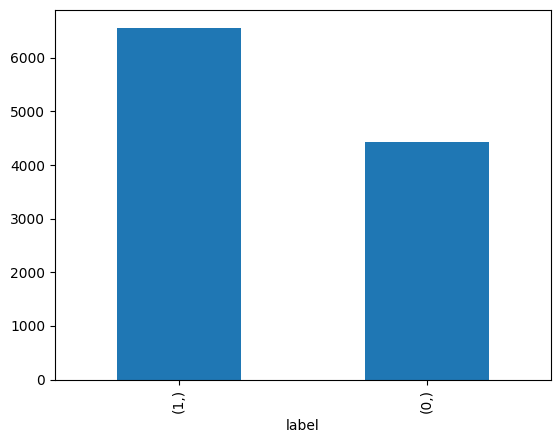

In [15]:
import matplotlib.pyplot as plt

pdf = df.select("label").toPandas()
pdf.value_counts().plot(kind="bar")
plt.show()

📌 Interpretasi

>EDA digunakan untuk memahami distribusi data dan keseimbangan kelas target sebelum dilakukan pemodelan.

🔹 c. Preprocessing Data

In [16]:
df = df.dropna()

Encoding kategorikal:

In [17]:
from pyspark.ml.feature import StringIndexer

cat_cols = [
    "Warehouse_block",
    "Mode_of_Shipment",
    "Product_importance",
    "Gender"
]

for c in cat_cols:
    indexer = StringIndexer(inputCol=c, outputCol=c+"_idx")
    df = indexer.fit(df).transform(df)

📌 Interpretasi

>Preprocessing dilakukan untuk meningkatkan kualitas data melalui penghapusan nilai kosong dan transformasi data kategorikal ke numerik.

🔹 d. Manipulasi Data (Spark SQL)

In [18]:
df.createOrReplaceTempView("shipping")

spark.sql("""
SELECT Mode_of_Shipment, AVG(Weight_in_gms) AS avg_weight
FROM shipping
GROUP BY Mode_of_Shipment
""").show()

+----------------+------------------+
|Mode_of_Shipment|        avg_weight|
+----------------+------------------+
|            Road| 3649.550568181818|
|            Ship|3631.4575180916645|
|          Flight|3629.3781654473833|
+----------------+------------------+



📌 Interpretasi

>Spark SQL digunakan untuk melakukan query analitik dan agregasi data secara terdistribusi.

🔹 e. Operasi RDD (ByKey)

In [19]:
rdd2 = df.select("Warehouse_block", "Cost_of_the_Product").rdd

avg_cost = rdd2.mapValues(lambda x: (x, 1)) \
    .reduceByKey(lambda a, b: (a[0]+b[0], a[1]+b[1])) \
    .mapValues(lambda x: x[0]/x[1])

avg_cost.collect()

[('D', 210.90785169029445),
 ('F', 209.0771958537916),
 ('A', 208.76759410801964),
 ('B', 212.1593016912166),
 ('C', 211.19148936170214)]

📌 Interpretasi

> Operasi RDD digunakan untuk melakukan agregasi data berbasis key secara manual menggunakan paradigma distributed processing.

✅ POINT 4

Machine Learning dengan MLlib

🔹 Feature Vector

In [20]:
from pyspark.ml.feature import VectorAssembler

features = [
    "Warehouse_block_idx",
    "Mode_of_Shipment_idx",
    "Customer_rating",
    "Cost_of_the_Product",
    "Prior_purchases",
    "Discount_offered",
    "Weight_in_gms"
]

assembler = VectorAssembler(
    inputCols=features,
    outputCol="features"
)

df = assembler.transform(df)

🔹 Split Data

In [21]:
train, test = df.randomSplit([0.8, 0.2], seed=42)

🔹 Model 1 – Logistic Regression

In [22]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label"
)

lr_model = lr.fit(train)
lr_pred = lr_model.transform(test)

🔹 Model 2 – Random Forest

In [23]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=50
)

rf_model = rf.fit(train)
rf_pred = rf_model.transform(test)

📌 Interpretasi Point 4

>Dua algoritma supervised learning digunakan untuk membandingkan performa model dalam memprediksi keterlambatan pengiriman.

✅ POINT 5

Hyperparameter Tuning

In [24]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="label"
)

paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [20, 50, 100]) \
    .addGrid(rf.maxDepth, [5, 10]) \
    .build()

cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3
)

cv_model = cv.fit(train)
cv_pred = cv_model.transform(test)

📌 Interpretasi Point 5

>Hyperparameter tuning dilakukan untuk mencari kombinasi parameter yang optimal pada model Random Forest.

✅ POINT 6

Evaluasi Model

In [25]:
print("AUC Logistic Regression:", evaluator.evaluate(lr_pred))
print("AUC Random Forest:", evaluator.evaluate(rf_pred))
print("AUC Random Forest Tuned:", evaluator.evaluate(cv_pred))

AUC Logistic Regression: 0.7283433241283317
AUC Random Forest: 0.7340594059405932
AUC Random Forest Tuned: 0.7184342515884223


📌 Interpretasi Point 6

> Evaluasi model dilakukan menggunakan metrik AUC. Berdasarkan hasil pengujian, model Random Forest tanpa hyperparameter tuning menghasilkan performa terbaik dibandingkan Logistic Regression dan Random Forest dengan tuning. Hal ini menunjukkan bahwa pada dataset ini, konfigurasi default Random Forest sudah cukup optimal.



✅ Tampilkan hasil prediksi



In [26]:
rf_pred.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

+-----+----------+-----------------------------------------+
|label|prediction|probability                              |
+-----+----------+-----------------------------------------+
|1    |1.0       |[0.007898784918849185,0.9921012150811508]|
|1    |1.0       |[0.19530455035230318,0.8046954496476968] |
|1    |1.0       |[0.006654297596945341,0.9933457024030546]|
|1    |1.0       |[0.02145183193739867,0.9785481680626014] |
|1    |1.0       |[0.005554785260933652,0.9944452147390663]|
|1    |1.0       |[0.007941023501099629,0.9920589764989003]|
|1    |1.0       |[0.009566773442263329,0.9904332265577367]|
|1    |1.0       |[0.005554785260933652,0.9944452147390663]|
|1    |1.0       |[0.17389885525885454,0.8261011447411454] |
|1    |1.0       |[0.007089622515719807,0.9929103774842802]|
+-----+----------+-----------------------------------------+
only showing top 10 rows




> Model Random Forest menghasilkan output berupa nilai prediksi kelas pengiriman dan probabilitas prediksi. Kolom prediction menunjukkan hasil klasifikasi model, sedangkan kolom probability menunjukkan tingkat keyakinan model terhadap prediksi tersebut. Hasil ini membuktikan bahwa model tidak hanya dievaluasi secara numerik, tetapi juga mampu menghasilkan prediksi pada data uji.



🎯 KESIMPULAN AKHIR

> Berdasarkan hasil eksperimen, model Random Forest tanpa hyperparameter tuning menghasilkan performa terbaik dalam memprediksi keterlambatan pengiriman dibandingkan Logistic Regression dan Random Forest dengan tuning. Hal ini menunjukkan bahwa pada dataset yang digunakan, konfigurasi default Random Forest sudah cukup optimal. Seluruh proses penelitian telah mengikuti pipeline Big Data mulai dari penyimpanan data, pemrosesan terdistribusi, analisis eksploratif, hingga pemodelan dan evaluasi menggunakan Apache Spark dan MLlib.